# Bài tập: Gradient Descent 2 biến

Notebook này dùng để luyện **Gradient Descent với hàm 2 biến**.

Mục tiêu chính:

- Hiểu cách tính gradient cho hàm 2 biến
- Biết cách cập nhật `x` và `y`
- Quan sát loss giảm dần qua từng epoch
- Hiểu ảnh hưởng của learning rate
- Biết viết hàm Gradient Descent tổng quát bằng Python

---

## Công thức tổng quát

Với hàm:

$$
f(x, y)
$$

Gradient là:

$$
\nabla f(x,y)=\left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)
$$

Công thức cập nhật:

$$
x_{new}=x-\eta \frac{\partial f}{\partial x}
$$

$$
y_{new}=y-\eta \frac{\partial f}{\partial y}
$$

Trong đó:

- $\eta$ là learning rate
- $\frac{\partial f}{\partial x}$ là đạo hàm riêng theo `x`
- $\frac{\partial f}{\partial y}$ là đạo hàm riêng theo `y`
- Ta đi ngược hướng gradient vì gradient là hướng làm hàm tăng nhanh nhất

# 1. Chuẩn bị thư viện

Ta dùng:

- `numpy` để tính toán số học
- `matplotlib` để vẽ biểu đồ loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Bài tập 1: Gradient Descent cho hàm đơn giản

Cho hàm:

$$
f(x,y)=x^2+y^2
$$

Yêu cầu:

1. Tính gradient của hàm.
2. Viết Gradient Descent để tìm điểm làm hàm nhỏ nhất.
3. In ra giá trị `x`, `y`, và `loss` qua từng epoch.

---

## Phân tích

Ta có:

$$
\frac{\partial f}{\partial x}=2x
$$

$$
\frac{\partial f}{\partial y}=2y
$$

Vậy gradient là:

$$
\nabla f(x,y)=(2x,2y)
$$

Hàm này nhỏ nhất tại:

$$
(x,y)=(0,0)
$$

vì:

$$
f(0,0)=0
$$

In [2]:
def f1(x, y):
    return x**2 + y**2


def grad_f1(x, y):
    dx = 2 * x
    dy = 2 * y
    return dx, dy


# Khởi tạo giá trị ban đầu
x = 4.0
y = 3.0

learning_rate = 0.1
epochs = 20

loss_history = []

for epoch in range(epochs):
    dx, dy = grad_f1(x, y)

    x = x - learning_rate * dx
    y = y - learning_rate * dy

    loss = f1(x, y)
    loss_history.append(loss)

    print(f"Epoch {epoch+1:02d}: x={x:.4f}, y={y:.4f}, loss={loss:.4f}")

Epoch 01: x=3.2000, y=2.4000, loss=16.0000
Epoch 02: x=2.5600, y=1.9200, loss=10.2400
Epoch 03: x=2.0480, y=1.5360, loss=6.5536
Epoch 04: x=1.6384, y=1.2288, loss=4.1943
Epoch 05: x=1.3107, y=0.9830, loss=2.6844
Epoch 06: x=1.0486, y=0.7864, loss=1.7180
Epoch 07: x=0.8389, y=0.6291, loss=1.0995
Epoch 08: x=0.6711, y=0.5033, loss=0.7037
Epoch 09: x=0.5369, y=0.4027, loss=0.4504
Epoch 10: x=0.4295, y=0.3221, loss=0.2882
Epoch 11: x=0.3436, y=0.2577, loss=0.1845
Epoch 12: x=0.2749, y=0.2062, loss=0.1181
Epoch 13: x=0.2199, y=0.1649, loss=0.0756
Epoch 14: x=0.1759, y=0.1319, loss=0.0484
Epoch 15: x=0.1407, y=0.1056, loss=0.0309
Epoch 16: x=0.1126, y=0.0844, loss=0.0198
Epoch 17: x=0.0901, y=0.0676, loss=0.0127
Epoch 18: x=0.0721, y=0.0540, loss=0.0081
Epoch 19: x=0.0576, y=0.0432, loss=0.0052
Epoch 20: x=0.0461, y=0.0346, loss=0.0033


## Giải thích code bài 1

Ban đầu ta chọn:

$$
x=4,\ y=3
$$

Loss ban đầu là:

$$
f(4,3)=4^2+3^2=16+9=25
$$

Ở mỗi epoch, chương trình làm 4 việc:

1. Tính gradient tại điểm hiện tại.
2. Cập nhật `x` bằng công thức Gradient Descent.
3. Cập nhật `y` bằng công thức Gradient Descent.
4. Tính lại loss sau khi cập nhật.

Ví dụ ở epoch đầu tiên:

$$
\frac{\partial f}{\partial x}=2x=2(4)=8
$$

$$
\frac{\partial f}{\partial y}=2y=2(3)=6
$$

Cập nhật:

$$
x_{new}=4-0.1(8)=3.2
$$

$$
y_{new}=3-0.1(6)=2.4
$$

Loss mới:

$$
f(3.2,2.4)=3.2^2+2.4^2=16
$$

Như vậy loss giảm từ `25` xuống `16`. Đây chính là ý nghĩa của Gradient Descent.

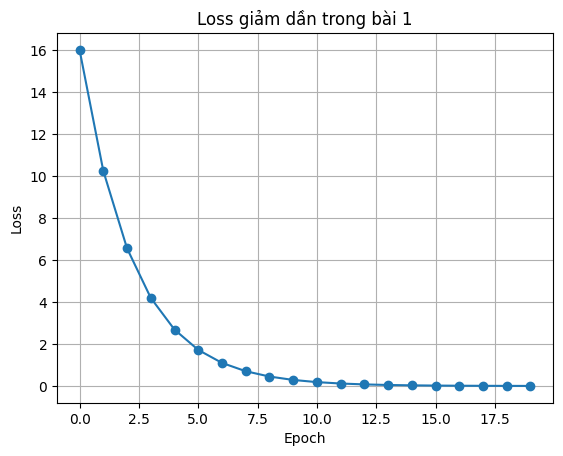

In [3]:
plt.plot(loss_history, marker='o')
plt.title('Loss giảm dần trong bài 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 3. Bài tập 2: Hàm có trọng số khác nhau

Cho hàm:

$$
f(x,y)=x^2+3y^2
$$

Yêu cầu:

1. Tính gradient.
2. Viết Gradient Descent.
3. So sánh tốc độ thay đổi của `x` và `y`.

---

## Phân tích

Ta có:

$$
\frac{\partial f}{\partial x}=2x
$$

$$
\frac{\partial f}{\partial y}=6y
$$

Vì hệ số của $y^2$ là `3`, nên gradient theo `y` lớn hơn so với bài 1.
Điều này làm `y` thay đổi mạnh hơn trong quá trình update.

In [4]:
def f2(x, y):
    return x**2 + 3 * y**2


def grad_f2(x, y):
    dx = 2 * x
    dy = 6 * y
    return dx, dy


x = 4.0
y = 3.0

learning_rate = 0.1
epochs = 20

loss_history = []

for epoch in range(epochs):
    dx, dy = grad_f2(x, y)

    x = x - learning_rate * dx
    y = y - learning_rate * dy

    loss = f2(x, y)
    loss_history.append(loss)

    print(f"Epoch {epoch+1:02d}: x={x:.4f}, y={y:.4f}, loss={loss:.4f}")

Epoch 01: x=3.2000, y=1.2000, loss=14.5600
Epoch 02: x=2.5600, y=0.4800, loss=7.2448
Epoch 03: x=2.0480, y=0.1920, loss=4.3049
Epoch 04: x=1.6384, y=0.0768, loss=2.7020
Epoch 05: x=1.3107, y=0.0307, loss=1.7208
Epoch 06: x=1.0486, y=0.0123, loss=1.1000
Epoch 07: x=0.8389, y=0.0049, loss=0.7038
Epoch 08: x=0.6711, y=0.0020, loss=0.4504
Epoch 09: x=0.5369, y=0.0008, loss=0.2882
Epoch 10: x=0.4295, y=0.0003, loss=0.1845
Epoch 11: x=0.3436, y=0.0001, loss=0.1181
Epoch 12: x=0.2749, y=0.0001, loss=0.0756
Epoch 13: x=0.2199, y=0.0000, loss=0.0484
Epoch 14: x=0.1759, y=0.0000, loss=0.0309
Epoch 15: x=0.1407, y=0.0000, loss=0.0198
Epoch 16: x=0.1126, y=0.0000, loss=0.0127
Epoch 17: x=0.0901, y=0.0000, loss=0.0081
Epoch 18: x=0.0721, y=0.0000, loss=0.0052
Epoch 19: x=0.0576, y=0.0000, loss=0.0033
Epoch 20: x=0.0461, y=0.0000, loss=0.0021


## Giải thích code bài 2

Điểm khác biệt lớn nhất nằm ở gradient theo `y`:

$$
\frac{\partial f}{\partial y}=6y
$$

Nếu ban đầu:

$$
y=3
$$

thì:

$$
\frac{\partial f}{\partial y}=6(3)=18
$$

Cập nhật:

$$
y_{new}=3-0.1(18)=1.2
$$

Ta thấy `y` giảm rất nhanh từ `3` xuống `1.2` ngay epoch đầu.

Trong khi đó:

$$
x_{new}=4-0.1(8)=3.2
$$

Vì vậy trong bài này, `y` bị kéo về 0 nhanh hơn `x`.

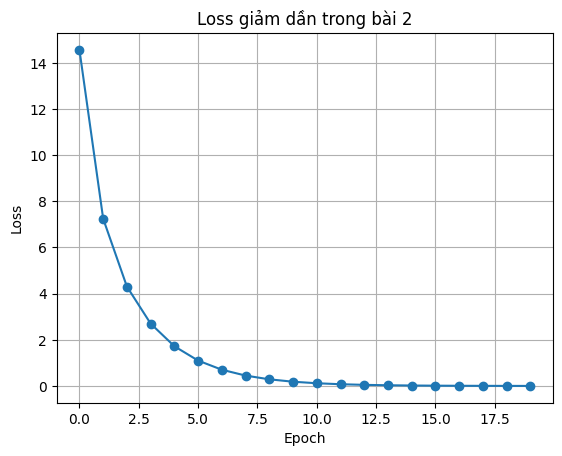

In [5]:
plt.plot(loss_history, marker='o')
plt.title('Loss giảm dần trong bài 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 4. Bài tập 3: Hàm có điểm minimum không nằm tại 0

Cho hàm:

$$
f(x,y)=(x-2)^2+(y+3)^2
$$

Yêu cầu:

1. Tìm gradient.
2. Dùng Gradient Descent để tìm minimum.
3. Kiểm tra xem nghiệm có tiến gần về $(2,-3)$ không.

---

## Phân tích

Hàm này nhỏ nhất khi:

$$
x-2=0 \Rightarrow x=2
$$

$$
y+3=0 \Rightarrow y=-3
$$

Vậy điểm minimum là:

$$
(2,-3)
$$

Gradient:

$$
\frac{\partial f}{\partial x}=2(x-2)
$$

$$
\frac{\partial f}{\partial y}=2(y+3)
$$

In [6]:
def f3(x, y):
    return (x - 2)**2 + (y + 3)**2


def grad_f3(x, y):
    dx = 2 * (x - 2)
    dy = 2 * (y + 3)
    return dx, dy


x = 10.0
y = 5.0

learning_rate = 0.1
epochs = 30

loss_history = []

for epoch in range(epochs):
    dx, dy = grad_f3(x, y)

    x = x - learning_rate * dx
    y = y - learning_rate * dy

    loss = f3(x, y)
    loss_history.append(loss)

    print(f"Epoch {epoch+1:02d}: x={x:.4f}, y={y:.4f}, loss={loss:.4f}")

Epoch 01: x=8.4000, y=3.4000, loss=81.9200
Epoch 02: x=7.1200, y=2.1200, loss=52.4288
Epoch 03: x=6.0960, y=1.0960, loss=33.5544
Epoch 04: x=5.2768, y=0.2768, loss=21.4748
Epoch 05: x=4.6214, y=-0.3786, loss=13.7439
Epoch 06: x=4.0972, y=-0.9028, loss=8.7961
Epoch 07: x=3.6777, y=-1.3223, loss=5.6295
Epoch 08: x=3.3422, y=-1.6578, loss=3.6029
Epoch 09: x=3.0737, y=-1.9263, loss=2.3058
Epoch 10: x=2.8590, y=-2.1410, loss=1.4757
Epoch 11: x=2.6872, y=-2.3128, loss=0.9445
Epoch 12: x=2.5498, y=-2.4502, loss=0.6045
Epoch 13: x=2.4398, y=-2.5602, loss=0.3869
Epoch 14: x=2.3518, y=-2.6482, loss=0.2476
Epoch 15: x=2.2815, y=-2.7185, loss=0.1585
Epoch 16: x=2.2252, y=-2.7748, loss=0.1014
Epoch 17: x=2.1801, y=-2.8199, loss=0.0649
Epoch 18: x=2.1441, y=-2.8559, loss=0.0415
Epoch 19: x=2.1153, y=-2.8847, loss=0.0266
Epoch 20: x=2.0922, y=-2.9078, loss=0.0170
Epoch 21: x=2.0738, y=-2.9262, loss=0.0109
Epoch 22: x=2.0590, y=-2.9410, loss=0.0070
Epoch 23: x=2.0472, y=-2.9528, loss=0.0045
Epoch 24: 

## Giải thích code bài 3

Ở bài 1 và bài 2, điểm nhỏ nhất đều nằm gần hoặc đúng tại `(0, 0)`.
Nhưng trong thực tế, minimum không nhất thiết nằm tại 0.

Với hàm:

$$
f(x,y)=(x-2)^2+(y+3)^2
$$

loss nhỏ nhất khi:

$$
x=2,\ y=-3
$$

Nếu chạy nhiều epoch, bạn sẽ thấy:

- `x` tiến dần về `2`
- `y` tiến dần về `-3`
- loss tiến dần về `0`

Đây là cách Gradient Descent đi tìm điểm tối ưu.

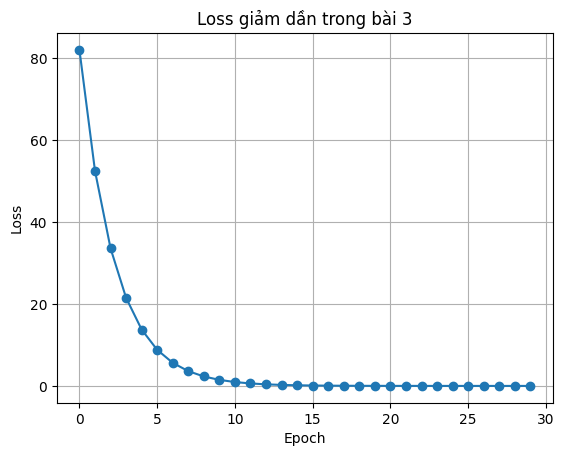

In [7]:
plt.plot(loss_history, marker='o')
plt.title('Loss giảm dần trong bài 3')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 5. Bài tập 4: Ảnh hưởng của Learning Rate

Dùng lại hàm:

$$
f(x,y)=x^2+y^2
$$

Thử các learning rate khác nhau:

- `0.01`
- `0.1`
- `0.5`
- `1.0`

Mục tiêu là quan sát:

- Learning rate nhỏ: học chậm
- Learning rate vừa: hội tụ tốt
- Learning rate lớn: có thể dao động hoặc không giảm loss

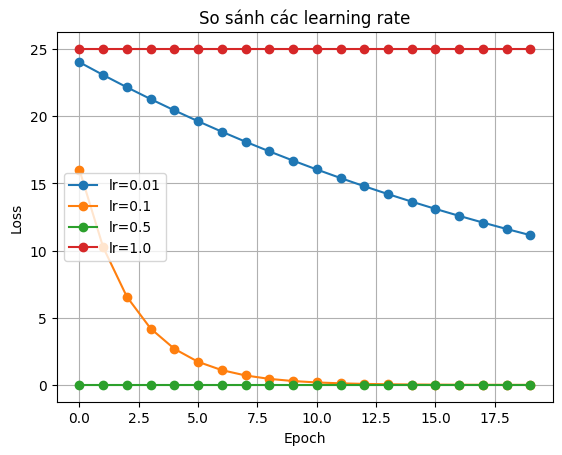

In [8]:
def run_gradient_descent_f1(lr, epochs=20):
    x = 4.0
    y = 3.0
    loss_history = []

    for epoch in range(epochs):
        dx, dy = grad_f1(x, y)

        x = x - lr * dx
        y = y - lr * dy

        loss = f1(x, y)
        loss_history.append(loss)

    return loss_history


learning_rates = [0.01, 0.1, 0.5, 1.0]

for lr in learning_rates:
    losses = run_gradient_descent_f1(lr)
    plt.plot(losses, marker='o', label=f'lr={lr}')

plt.title('So sánh các learning rate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Giải thích bài 4

Learning rate là độ dài bước nhảy khi ta cập nhật tham số.

Nếu learning rate quá nhỏ, model đi rất chậm. Giống như muốn xuống núi nhưng mỗi bước chỉ nhích một chút.

Nếu learning rate vừa phải, loss giảm nhanh và ổn định.

Nếu learning rate quá lớn, model có thể nhảy quá xa khỏi điểm minimum. Khi đó loss có thể dao động hoặc không giảm.

Với hàm:

$$
f(x,y)=x^2+y^2
$$

learning rate `1.0` là trường hợp đặc biệt. Công thức update là:

$$
x_{new}=x-1.0(2x)=-x
$$

$$
y_{new}=y-1.0(2y)=-y
$$

Nghĩa là điểm sẽ nhảy qua lại giữa hai phía, ví dụ từ `(4,3)` sang `(-4,-3)`, rồi lại quay về `(4,3)`. Loss không giảm.

Đây là lý do trong Machine Learning, chọn learning rate rất quan trọng.

# 6. Bài tập 5: Viết hàm Gradient Descent tổng quát

Thay vì viết lại code nhiều lần, ta viết một hàm tổng quát.

Hàm này nhận vào:

- `func`: hàm loss
- `grad_func`: hàm gradient
- `x_start`, `y_start`: điểm bắt đầu
- `learning_rate`: tốc độ học
- `epochs`: số lần lặp

Sau đó trả về:

- `x`, `y` cuối cùng
- danh sách loss qua từng epoch

In [9]:
def gradient_descent_2d(func, grad_func, x_start, y_start, learning_rate=0.1, epochs=50):
    x = float(x_start)
    y = float(y_start)

    history = []

    for epoch in range(epochs):
        dx, dy = grad_func(x, y)

        x = x - learning_rate * dx
        y = y - learning_rate * dy

        loss = func(x, y)

        history.append({
            'epoch': epoch + 1,
            'x': x,
            'y': y,
            'loss': loss
        })

    return x, y, history

## Áp dụng hàm tổng quát cho bài 3

Ta thử tìm minimum của:

$$
f(x,y)=(x-2)^2+(y+3)^2
$$

Kỳ vọng kết quả cuối cùng gần:

$$
(2,-3)
$$

In [10]:
x_final, y_final, history = gradient_descent_2d(
    func=f3,
    grad_func=grad_f3,
    x_start=10,
    y_start=5,
    learning_rate=0.1,
    epochs=40
)

print(f"x cuối cùng: {x_final:.6f}")
print(f"y cuối cùng: {y_final:.6f}")
print(f"loss cuối cùng: {history[-1]['loss']:.8f}")

x cuối cùng: 2.001063
y cuối cùng: -2.998937
loss cuối cùng: 0.00000226


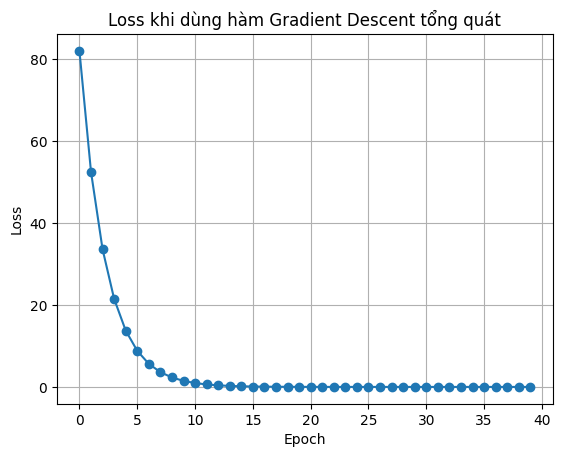

In [11]:
losses = [item['loss'] for item in history]

plt.plot(losses, marker='o')
plt.title('Loss khi dùng hàm Gradient Descent tổng quát')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Giải thích bài 5

Hàm `gradient_descent_2d` giúp ta tái sử dụng code.

Thay vì mỗi bài lại viết lại vòng lặp:

```python
for epoch in range(epochs):
    dx, dy = ...
    x = x - learning_rate * dx
    y = y - learning_rate * dy
```

Ta chỉ cần thay:

- hàm loss
- hàm gradient
- điểm bắt đầu
- learning rate
- số epoch

Cách viết này giống tư duy trong Machine Learning thật: thuật toán tối ưu giữ nguyên, chỉ thay hàm loss và gradient.

# 7. Bài tập 6: Gradient Descent cho Linear Regression 2 tham số

Đây là bài quan trọng nhất vì nó gần với Machine Learning thật.

Ta có model Linear Regression:

$$
\hat{y}=w x + b
$$

Trong đó:

- `w` là weight
- `b` là bias
- `x` là input
- `y_hat` là dự đoán

Loss dùng MSE:

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2
$$

Mục tiêu là tìm `w` và `b` sao cho MSE nhỏ nhất.

In [12]:
# Dữ liệu giả lập đơn giản
X = np.array([1, 2, 3, 4, 5], dtype=float)
y_true = np.array([3, 5, 7, 9, 11], dtype=float)

# Dữ liệu này đi theo quy luật: y = 2x + 1

## Công thức gradient cho Linear Regression

Model:

$$
\hat{y}=wx+b
$$

Loss:

$$
MSE=\frac{1}{n}\sum(\hat{y}-y)^2
$$

Gradient theo `w`:

$$
\frac{\partial MSE}{\partial w}=\frac{2}{n}\sum(\hat{y}-y)x
$$

Gradient theo `b`:

$$
\frac{\partial MSE}{\partial b}=\frac{2}{n}\sum(\hat{y}-y)
$$

Ở đây Gradient Descent 2 biến chính là cập nhật 2 tham số:

- `w`
- `b`

In [13]:
def predict(X, w, b):
    return w * X + b


def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


def gradients_linear_regression(X, y_true, w, b):
    n = len(X)
    y_pred = predict(X, w, b)

    dw = (2 / n) * np.sum((y_pred - y_true) * X)
    db = (2 / n) * np.sum(y_pred - y_true)

    return dw, db

In [15]:
# Khởi tạo w và b
w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 200

loss_history = []

for epoch in range(epochs):
    dw, db = gradients_linear_regression(X, y_true, w, b)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    y_pred = predict(X, w, b)
    loss = mse_loss(y_pred, y_true)
    loss_history.append(loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}: w={w:.4f}, b={b:.4f}, loss={loss:.4f}")

print("Kết quả cuối cùng:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")

Epoch 020: w=2.0977, b=0.6102, loss=0.0284
Epoch 040: w=2.1002, b=0.6382, loss=0.0238
Epoch 060: w=2.0936, b=0.6619, loss=0.0208
Epoch 080: w=2.0875, b=0.6841, loss=0.0182
Epoch 100: w=2.0818, b=0.7048, loss=0.0159
Epoch 120: w=2.0764, b=0.7241, loss=0.0139
Epoch 140: w=2.0714, b=0.7422, loss=0.0121
Epoch 160: w=2.0667, b=0.7590, loss=0.0106
Epoch 180: w=2.0624, b=0.7748, loss=0.0092
Epoch 200: w=2.0583, b=0.7896, loss=0.0081
Kết quả cuối cùng:
w = 2.0583
b = 0.7896


## Giải thích bài 6

Dữ liệu được tạo theo quy luật:

$$
y=2x+1
$$

Nên kết quả lý tưởng là:

$$
w=2,\ b=1
$$

Ban đầu ta cho:

$$
w=0,\ b=0
$$

Tức là model dự đoán rất sai.

Sau mỗi epoch:

1. Model dự đoán `y_pred`.
2. Tính sai số giữa `y_pred` và `y_true`.
3. Tính gradient theo `w` và `b`.
4. Cập nhật `w` và `b`.
5. Loss giảm dần.

Đây chính là cách model Linear Regression học từ dữ liệu.

Điểm quan trọng: trong bài này, hai biến của Gradient Descent không còn gọi là `x` và `y` nữa, mà là `w` và `b`. Nhưng bản chất vẫn là Gradient Descent 2 biến.

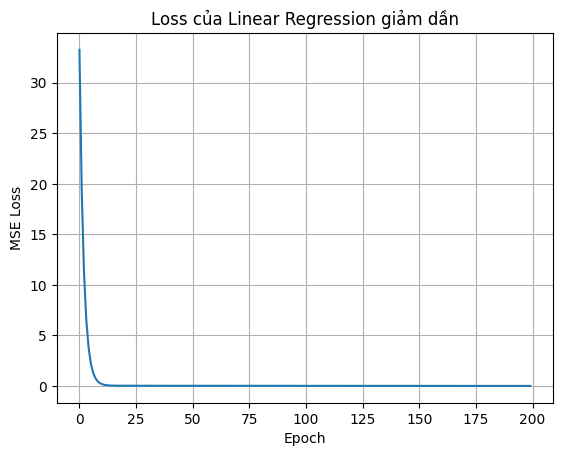

In [16]:
plt.plot(loss_history)
plt.title('Loss của Linear Regression giảm dần')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

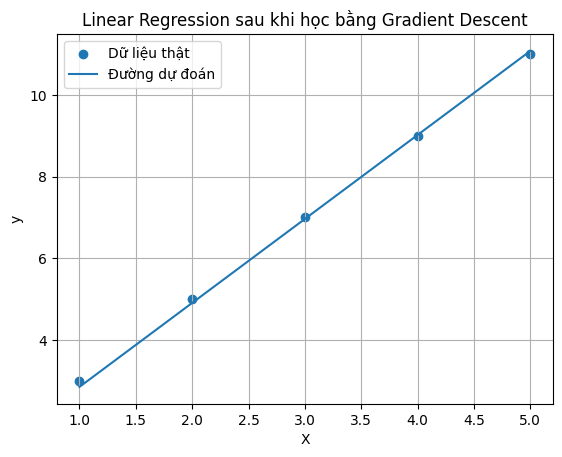

In [17]:
plt.scatter(X, y_true, label='Dữ liệu thật')
plt.plot(X, predict(X, w, b), label='Đường dự đoán')
plt.title('Linear Regression sau khi học bằng Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 8. Bài tập tự luyện

## Bài tự luyện 1

Viết Gradient Descent cho hàm:

$$
f(x,y)=2x^2+y^2
$$

Gợi ý:

$$
\frac{\partial f}{\partial x}=4x
$$

$$
\frac{\partial f}{\partial y}=2y
$$

---

## Bài tự luyện 2

Viết Gradient Descent cho hàm:

$$
f(x,y)=(x+4)^2+(y-1)^2
$$

Minimum nằm tại đâu?

---

## Bài tự luyện 3

Thử đổi learning rate trong bài Linear Regression:

- `0.001`
- `0.01`
- `0.1`

Quan sát xem loss thay đổi như thế nào.

# 9. Tổng kết

Gradient Descent 2 biến có thể hiểu đơn giản như sau:

1. Có một hàm loss phụ thuộc vào 2 biến.
2. Ta tính gradient theo từng biến.
3. Mỗi biến được cập nhật theo hướng làm loss giảm.
4. Lặp lại nhiều lần cho đến khi loss đủ nhỏ.

Trong Machine Learning thật:

- 2 biến có thể là `w` và `b`
- nhiều biến hơn thì là nhiều weights
- Deep Learning có thể có hàng nghìn, hàng triệu, thậm chí hàng tỷ tham số

Nhưng cốt lõi vẫn là:

$$
\text{tham số mới} = \text{tham số cũ} - \text{learning rate} \times \text{gradient}
$$

Đây là một trong những nền móng quan trọng nhất của AI/ML.